In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/delivery_data.csv")

In [3]:
route_summary = df.groupby("route_type").agg({
    "actual_time": "mean",
    "osrm_time": "mean",
    "factor": "mean",
    "segment_factor": "mean"
}).round(2)

route_summary

,actual_time,osrm_time,factor,segment_factor
route_type,,,,
Carting,70.64,30.45,2.41,2.60
FTL,574.01,297.07,1.99,2.04


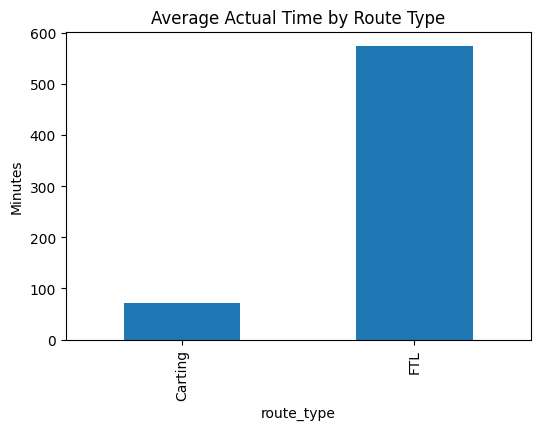

In [4]:
route_summary["actual_time"].plot(
    kind="bar",
    figsize=(6,4),
    title="Average Actual Time by Route Type"
)

plt.ylabel("Minutes")
plt.show()

In [5]:
plt.savefig("../graphs/ftl_vs_carting_actual_time.png")

<Figure size 640x480 with 0 Axes>

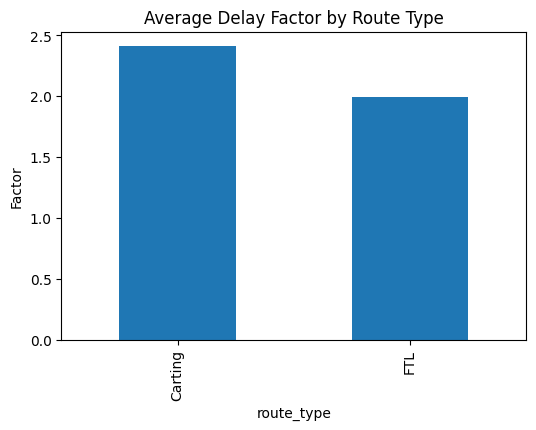

In [6]:
route_summary["factor"].plot(
    kind="bar",
    figsize=(6,4),
    title="Average Delay Factor by Route Type"
)

plt.ylabel("Factor")
plt.show()

In [7]:
plt.savefig("../graphs/ftl_vs_carting_delay_factor.png")

<Figure size 640x480 with 0 Axes>

In [8]:
distance_summary = df.groupby("route_type")[
    "osrm_distance"
].mean()

distance_summary

route_type
Carting     34.311987
FTL        398.382716
Name: osrm_distance, dtype: float64

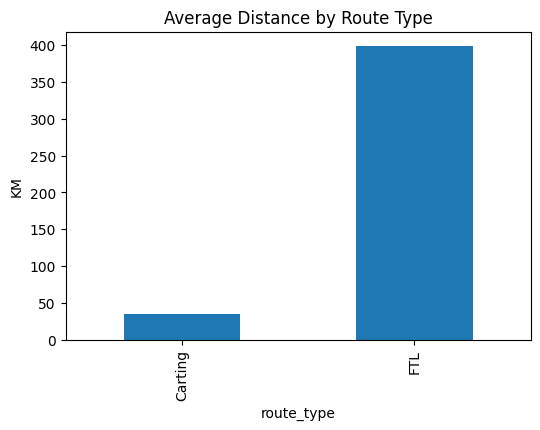

In [9]:
distance_summary.plot(
    kind="bar",
    figsize=(6,4),
    title="Average Distance by Route Type"
)

plt.ylabel("KM")
plt.show()

In [10]:
plt.savefig("../graphs/ftl_vs_carting_distance.png")

<Figure size 640x480 with 0 Axes>

In [11]:
print("""
FTL vs Carting Framework

1. Use FTL for long-haul routes (>300 km).
2. Use FTL on bottleneck corridors with high delay factors.
3. Use Carting for short-distance urban deliveries.
4. Prioritize FTL when SLA compliance is critical.
5. Use graph bottleneck scores to identify routes needing FTL upgrades.
""")


FTL vs Carting Framework

1. Use FTL for long-haul routes (>300 km).
2. Use FTL on bottleneck corridors with high delay factors.
3. Use Carting for short-distance urban deliveries.
4. Prioritize FTL when SLA compliance is critical.
5. Use graph bottleneck scores to identify routes needing FTL upgrades.



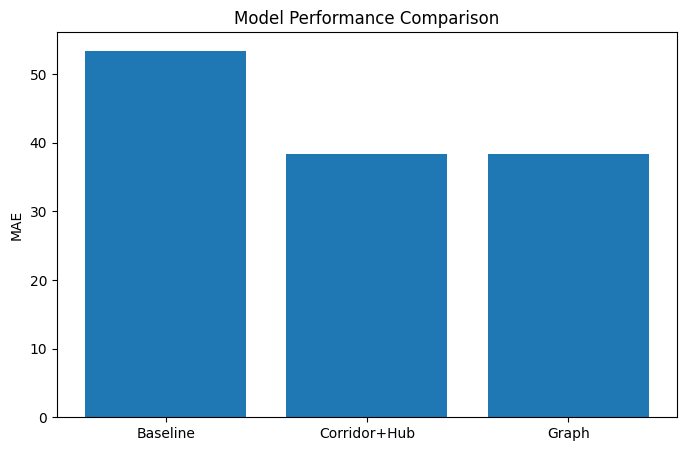

In [12]:
import matplotlib.pyplot as plt

models = [
    "Baseline",
    "Corridor+Hub",
    "Graph"
]

mae = [
    53.40,
    38.39,
    38.31
]

plt.figure(figsize=(8,5))

plt.bar(models, mae)

plt.ylabel("MAE")
plt.title("Model Performance Comparison")

plt.savefig("../graphs/model_comparison.png")

plt.show()

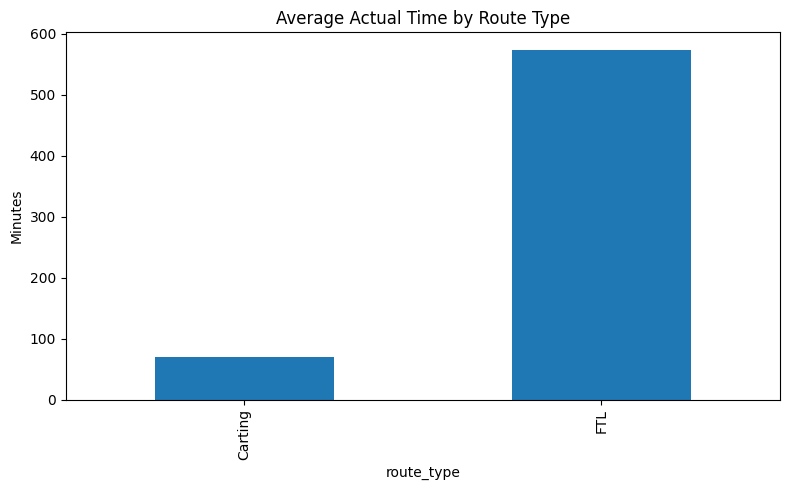

In [13]:
import matplotlib.pyplot as plt

route_summary["actual_time"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Actual Time by Route Type")
plt.ylabel("Minutes")

plt.tight_layout()

plt.savefig("../graphs/ftl_vs_carting_actual_time.png")

plt.show()

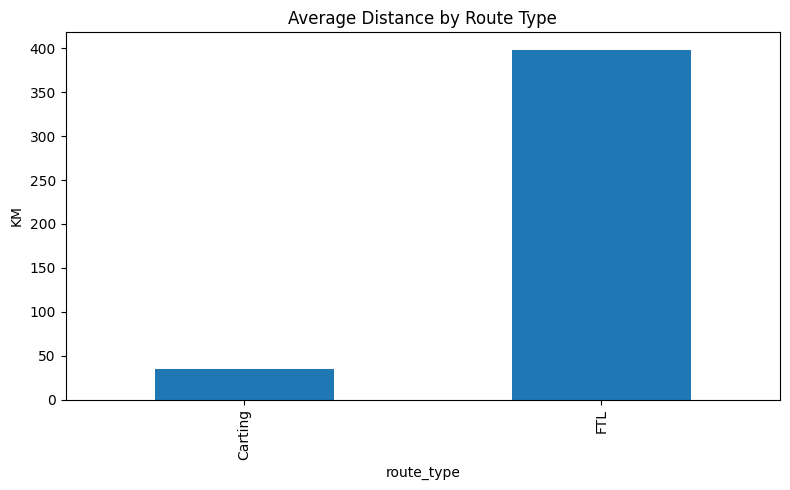

In [14]:
distance_summary.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Distance by Route Type")
plt.ylabel("KM")

plt.tight_layout()

plt.savefig("../graphs/ftl_vs_carting_distance.png")

plt.show()

In [15]:
print(route_summary)

            actual_time  osrm_time  factor  segment_factor
route_type                                                
Carting           70.64      30.45    2.41            2.60
FTL              574.01     297.07    1.99            2.04


In [ ]:
X = df[features]

X = X.apply(pd.to_numeric, errors="coerce")

X = X.fillna(0)

y = df["actual_time"]

groups = df["trip_uuid"]

print(X.dtypes)

osrm_time                         float64
osrm_distance                     float64
actual_distance_to_destination    float64
cutoff_factor                       int64
route_type                          int64
corridor_median_factor            float64
corridor_trip_count                 int64
corridor_p90_factor               float64
hub_outbound_delay                float64
hub_trip_volume                     int64
hub_inbound_delay                 float64
source_betweenness                float64
source_pagerank                   float64
source_out_degree                   int64
destination_betweenness           float64
destination_pagerank              float64
destination_in_degree               int64
dtype: object
